### Covariance Matrix Decomposition

We're going to compute the covariance matrix of a simple but large dataset to perform a dimension reduction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # SVD decomposition by scikit-learn

plt.style.use('dark_background')

In [2]:
original_dataset = pd.read_csv('SOCR-HeightWeight.csv') # Original dataset
original_dataset

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [3]:
original_dataset.drop(columns ='Index', inplace = True) # Drop the "Index" column, we don't need it

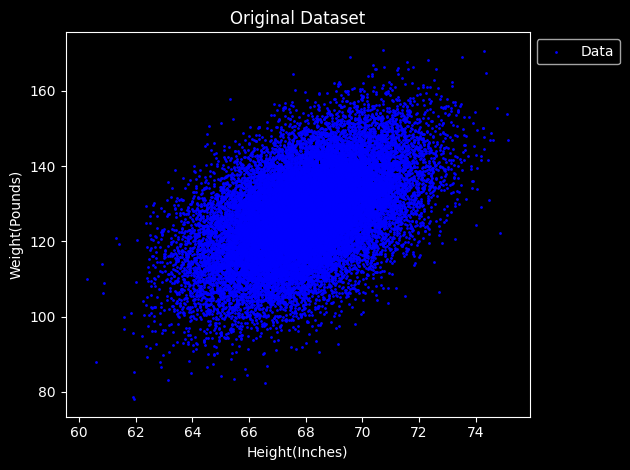

In [4]:
# Data visualization
original_dataset.plot(x = 'Height(Inches)', y = 'Weight(Pounds)', kind = 'scatter', s = 1, color = 'blue', label = 'Data')
plt.title('Original Dataset')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.tight_layout()
plt.show()

Let's center the dataset using mean values

In [5]:
centered_dataset = original_dataset - original_dataset.mean()
centered_dataset

,Height(Inches),Weight(Pounds)
0,-2.209804,-14.086921
1,3.522096,9.407879
2,1.405626,25.947479
3,0.223486,15.255979
4,-0.205304,17.217679
...,...,...
24995,1.509036,-9.048221
24996,-3.444854,-6.886221
24997,-3.294564,-8.813921
24998,-0.463934,5.188779


Let's compute the covariance matrix of the centered dataset

In [6]:
cov_matrix = centered_dataset.cov() # Covariance matrix height vs weight
cov_matrix

,Height(Inches),Weight(Pounds)
Height(Inches),3.616382,11.151029
Weight(Pounds),11.151029,135.976532


This matrix is symmetric. By spectral theorem, we can decompose it:

$$
    \mathcal{Cov} = \mathcal{Q} \, \mathcal{\Lambda} \, \mathcal{Q}^{T}
$$

Where $\mathcal{Q}$ is an orthogonal matrix built using eigenvectors of $\mathcal{Cov}$, and $\mathcal{\Lambda}$ is a diagonal matrix, containing the eigenvalues of $\mathcal{Cov}$

In [7]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix, UPLO = 'L') # Computing eigenvalues and eigenvectors of the covariance matrix

In [8]:
eigenvalues

array([  2.68350923, 136.90940491])

In [9]:
eigenvectors # (Normalized by NumPy)

array([[-0.99651893,  0.08336679],
       [ 0.08336679,  0.99651893]])

In [10]:
# Proof: we did right
Q = eigenvectors.copy() # Q columns are the eigenvectors of the covariance matrix
Lambda = np.diag(eigenvalues) # Lambda's diagonal contains the eigenvalues of the covariance matrix
Q @ Lambda @ Q.T # Covariance matrix

array([[  3.61638215,  11.15102917],
       [ 11.15102917, 135.97653199]])

Mathematically, $\mathcal{Q}$ describes a reflection across a line making an angle $\theta$ with the x-axis:

$$
    \theta = \frac{1}{2} \, \operatorname{tan}^{-1} \, (\mathcal{Q}_{1,0}, \, \mathcal{Q}_{0, 0})
$$

In [11]:
theta = 0.5 * np.atan2(Q[1, 0], Q[0, 0])
theta # Radians

np.float64(1.529064495898954)

In [12]:
Q # Q matrix

array([[-0.99651893,  0.08336679],
       [ 0.08336679,  0.99651893]])

In [13]:
np.cos(2 * theta), np.sin(2 * theta) # Coefficients of Q refound

(np.float64(-0.9965189300983253), np.float64(0.0833667916840335))

We can visualize the eigenvectors

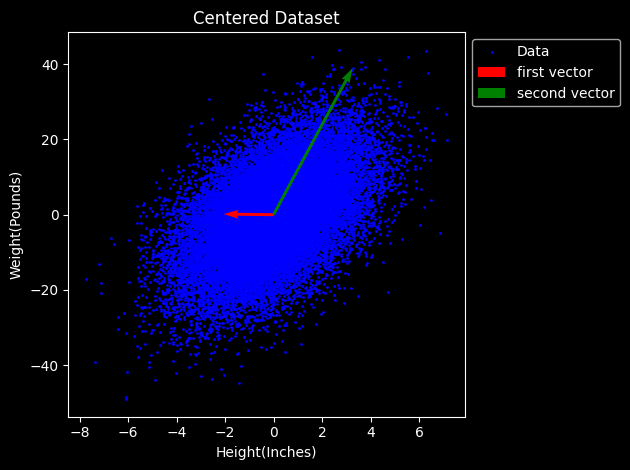

In [14]:
# Eigenvectors visualization
centered_dataset.plot(x = 'Height(Inches)', y = 'Weight(Pounds)', kind = 'scatter', s = 1, color = 'blue', label = 'Data')
plt.quiver(0, 0, eigenvalues[0] * eigenvectors[:, 0][0], eigenvalues[0] * eigenvectors[:, 0][1],
           angles = 'xy',
           scale_units = 'xy',
           scale = 1.3,
           color = 'red',
           label = 'first vector')
plt.quiver(0, 0, eigenvalues[1] * eigenvectors[:, 1][0], eigenvalues[1] * eigenvectors[:, 1][1],
           angles = 'xy',
           scale_units = 'xy',
           scale = 3.5,
           color = 'green',
           label = 'second vector')
plt.title('Centered Dataset')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))

plt.tight_layout()
plt.show()

The second eigenvalue is much bigger than the first one, so we can transform the original dataset to reduce its number of features to only one. We do not lose statistics though

In [15]:
centered_dataset @ Q # Dataset transformation: only the second column counts. Mathematically, we are reflecting the data points by applying the reflection matrix Q

,0,1
0,1.027730,-14.222108
1,-2.725531,9.668755
2,0.762425,25.974336
3,1.049134,15.221503
4,1.639972,17.140627
...,...,...
24995,-2.258105,-8.890920
24996,2.858780,-7.149436
24997,2.548307,-9.057896
24998,0.894890,5.132040


In [16]:
pca = PCA( # PCA class from scikit-learn
    n_components = 2, # Height, Weight
    copy = True,
    whiten = False,
    svd_solver = 'auto',
    iterated_power = 'auto',
    power_iteration_normalizer = 'auto',
    random_state = 47
)

In [17]:
pca.fit(centered_dataset) # SVD

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",47
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to en

In [18]:
pca.components_ # Q, different order and different sign though

array([[ 0.08336679,  0.99651893],
       [ 0.99651893, -0.08336679]])

In [19]:
pca.explained_variance_ # Lambda in descent order

array([136.90940491,   2.68350923])

In [20]:
pca.explained_variance_ratio_ # The first eigenvalue explains almost all variance of the dataset

array([0.98077618, 0.01922382])

In [21]:
pca.singular_values_ # Sigma matrix values (SVD)

array([1850.02654396,  259.00781294])

Now we can apply the transformation to the centered dataset

In [22]:
new_dataset = pca.transform(centered_dataset) # The sign of the second column doesn't matter. It depends on algorithm implementation. Only the first column matters
new_dataset

array([[-14.22210784,  -1.02772969],
       [  9.66875523,   2.72553106],
       [ 25.97433642,  -0.76242474],
       ...,
       [ -9.05789648,  -2.54830666],
       [  5.13203968,  -0.89489046],
       [ -2.123807  ,   1.06525962]], shape=(25000, 2))

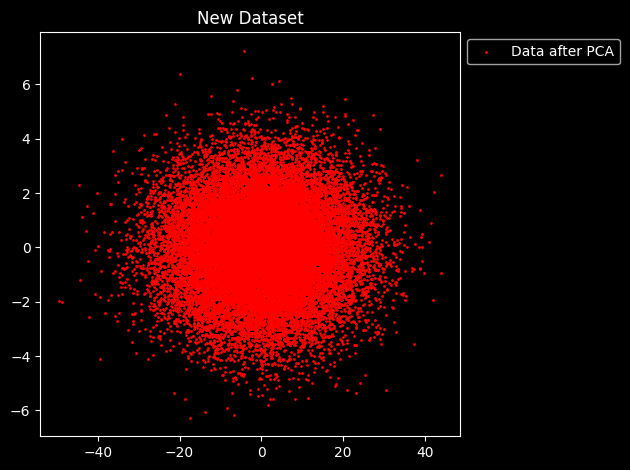

In [23]:
# New Data visualization
plt.title('New Dataset')
plt.scatter(new_dataset[:,0], new_dataset[:,1], c = 'red', s = 1, label = 'Data after PCA')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.tight_layout()
plt.show()